In [71]:
import sys
import os
import pandas as pd

wor_dir = "/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis"
os.chdir(wor_dir)

#sys.path.append("../../..")
from BERT_classifier.Train_BERT import BERT_Training_NO_class
from NACE_helper import NACE_code_structure


#BERT_Training_NO_class.train_BERT_model()

In [76]:
################################################
#### CONFIG
################################################

subtree_of_level = 1
nace_level = subtree_of_level + 1
#subtree_of_class = "A"

data_aggregation_method = 2
dataset_version = 2
train_full_model = True
all_labels = False
model_name = "ProsusAI/finbert"
model_name = "bert-base-uncased"
num_layers = 2
new_thresh = 0.35
only_labels = True # if False also train a "no-class" class

In [77]:
level_1_classes = ["C", "K"]
level_1_classes = ["K"]
level_1_classes = ["C"]
level_1_classes = ["A", "K"]
level_1_classes = ["A", "C", "K"]

if subtree_of_level == 1: 
    classes = level_1_classes
elif subtree_of_level == 2: 
    classes = []
    for subtree_of_class in level_1_classes:
        subtree_classes = NACE_code_structure.level_2[subtree_of_class]    
        classes.extend(subtree_classes)

In [78]:
mypath = '/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis/'

In [79]:
for subtree_of_class in classes:

    if subtree_of_level == 1: 
        subtree_classes = NACE_code_structure.level_2[subtree_of_class]
    if subtree_of_level == 2: 
        subtree_classes = NACE_code_structure.level_3[subtree_of_class]
    
    data_path = mypath + f"data/training_data/approach_{data_aggregation_method}/dataset__reports_subset_from_full_data_{dataset_version}_sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_{nace_level}__2nd_approach__nace_level_{nace_level}__cos_thres_{new_thresh}"
    #data_path = "/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis/data/training_data/approach_2/dataset__reports_subset_from_full_data_2_sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_2__2nd_approach__nace_level_2__cos_thres_0.35"

    data_files = {"train": os.path.join(data_path, "train_data.csv"), "test": os.path.join(data_path, "test_data.csv"), "validation": os.path.join(data_path, "val_data.csv")}
    # Load the CSV files using pandas
    train_df = pd.read_csv(data_files["train"])
    train_df  = train_df[train_df["NACE_Code"].apply(lambda x: x in subtree_classes)]
    
    print("-------")
    #print(f"For subtree of class {subtree_of_class} train a classifier with the following classes: {subtree_classes}")
    print(f"{subtree_of_class} -> {subtree_classes}")
    print(train_df["NACE_Code"].value_counts().to_dict())
    # print(set(train_df["NACE_Code"]))
    # print(subtree_classes)

-------
A -> ['1', '2', '3']
{'3': 1224, '1': 563, '2': 257}
-------
C -> ['10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33']
{'21': 1834, '26': 568, '10': 568, '30': 162, '23': 148, '27': 137, '28': 130, '29': 122, '19': 121, '17': 118, '24': 44, '13': 39, '14': 36, '11': 33, '22': 29, '18': 13, '32': 9, '15': 4, '20': 4, '16': 2, '31': 2}
-------
K -> ['64', '65', '66']
{'65': 7572, '64': 817, '66': 286}


In [ ]:
# count_classes_train = train_df.groupby("NACE_Code").count()["Score"].to_dict()
# print(count_classes_train)
# drop_classes = [k for k, v in count_classes_train.items() if v < 80]
# drop_classes

# for drop_class in drop_classes: 
    
#     train_df = train_df[train_df["NACE_Code"] != drop_class]
#     test_df = test_df[test_df["NACE_Code"] != drop_class]
#     validation_df = validation_df[validation_df["NACE_Code"] != drop_class]
# print(count_classes_train)

['01.1', '01.2', '01.3', '01.4', '01.5', '01.6', '01.7']


Map:   0%|          | 0/231 [00:00<?, ? examples/s]

Map:   0%|          | 0/84 [00:00<?, ? examples/s]

Map:   0%|          | 0/69 [00:00<?, ? examples/s]

Map:   0%|          | 0/231 [00:00<?, ? examples/s]

...

Epoch,Training Loss,Validation Loss,F1
1,0.642100,0.476436,0.864869
2,0.326600,0.250556,0.913868
3,0.119900,0.055942,0.985552
4,0.099800,0.129313,0.971179
5,0.029700,0.334595,0.926654


/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis/nace_git/lib/python3.10/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis/nace_git/lib/python3.10/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis/nace_git/lib/python3.10/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/data/resources/weichel-llama3/work/projects/nace_classification

{'eval_loss': 0.05594158545136452, 'eval_f1': 0.9855516929377588, 'eval_runtime': 6.4495, 'eval_samples_per_second': 10.699, 'eval_steps_per_second': 0.775, 'epoch': 5.0}


/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis/nace_git/lib/python3.10/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


              precision    recall  f1-score   support

           0       1.00      0.98      0.99        46
           1       0.97      1.00      0.99        38

    accuracy                           0.99        84
   macro avg       0.99      0.99      0.99        84
weighted avg       0.99      0.99      0.99        84



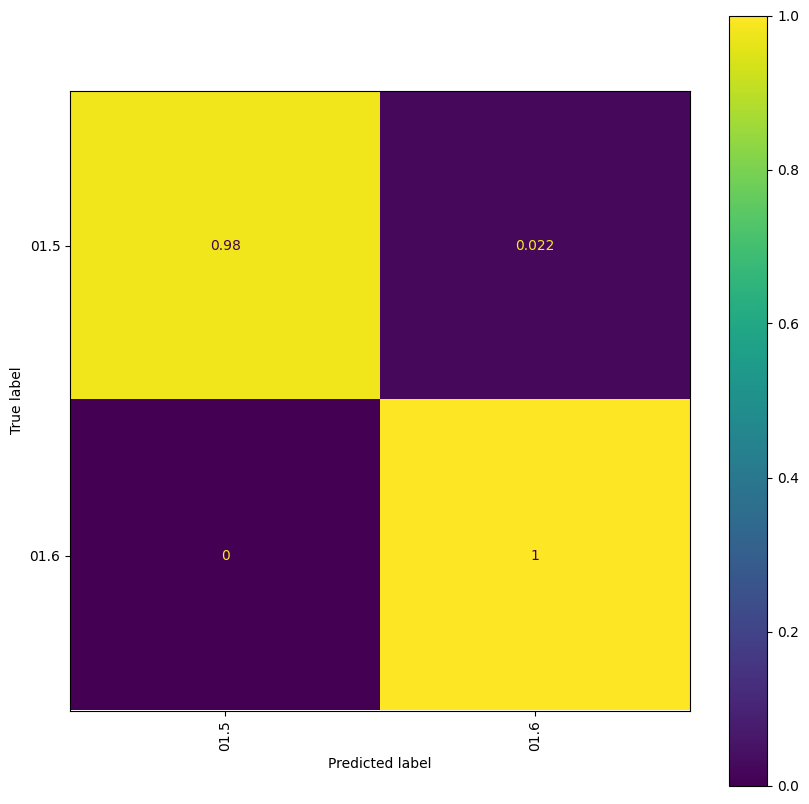

Best threshold: 0.01
Best macro F1: 0.988011988011988
['02.1', '02.2', '02.3', '02.4']


IndexError: Invalid key: 0 is out of bounds for size 0

<Figure size 640x480 with 0 Axes>

<Figure size 800x500 with 0 Axes>

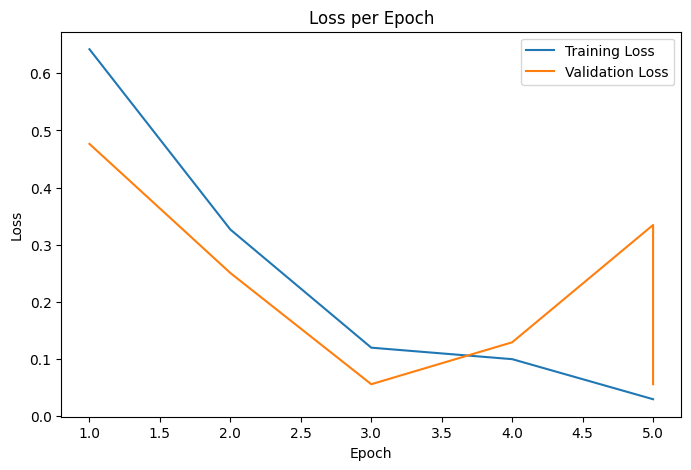

In [20]:
for subtree_of_class in classes:

    if subtree_of_level == 1: 
        subtree_classes = NACE_code_structure.level_2[subtree_of_class]
    if subtree_of_level == 2: 
        subtree_classes = NACE_code_structure.level_3[subtree_of_class]
    
    print(subtree_classes)
    
    # get dataset
    
    mypath = "/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis/"
                    #data_path = "/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/data/test_read_training_data_right_classifications/paragraph_and_sentence_len_5_min_chunk_len_100_cos_thresh_0.4_nace_level_1_stoxx_with_null/"
    
    data_path = mypath + f"data/training_data/approach_{data_aggregation_method}/dataset__reports_subset_from_full_data_{dataset_version}_sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_{nace_level}__2nd_approach__nace_level_{nace_level}__cos_thres_{new_thresh}"
    dataset_description = f"data_approach_{data_aggregation_method}"
    
    results_path = mypath + f"results/BERT_models/NACE_classification/NACE_level_{nace_level}/NACE_class_{subtree_of_class}/"
                    
    experiment_nbr = BERT_Training_NO_class.get_experiment_nbr(results_path)
    results_path = results_path + f"{experiment_nbr}_results__{dataset_description}__num_layers_{num_layers}__cos_thres_{new_thresh}" + os.path.basename(model_name)
    
    if train_full_model:
        results_path += "__train_full_model" 
    else: 
        results_path += "__train_classifier_only" 
    
    if all_labels: 
        results_path += "__all_labels" 
    else: 
        results_path += "__some_labels_no_G" 
    if only_labels: 
        results_path += "__only_labels" 
    else: 
        results_path += "__with_no_class" 
    
    data_files = {"train": os.path.join(data_path, "train_data.csv"), "test": os.path.join(data_path, "test_data.csv"), "validation": os.path.join(data_path, "val_data.csv")}
    # Load the CSV files using pandas
    train_df = pd.read_csv(data_files["train"])
    test_df = pd.read_csv(data_files["test"])
    validation_df = pd.read_csv(data_files["validation"])
                
    train_df = train_df[(train_df["Score"] > new_thresh) | (train_df["NACE_Code"] == "NO_CLASS")]
    validation_df = validation_df[(validation_df["Score"] > new_thresh) | (test_df["NACE_Code"] == "NO_CLASS")]
    test_df = test_df[(test_df["Score"] > new_thresh) | (test_df["NACE_Code"] == "NO_CLASS")]
            
    if not all_labels: 
        #train_df = train_df[train_df["NACE_Code"]!="C"]
        #train_df = train_df[train_df["NACE_Code"]!="P"]
        #train_df = train_df[train_df["NACE_Code"]!="M"]
        #train_df = train_df[train_df["NACE_Code"]!="M"]
        train_df = train_df[train_df["NACE_Code"]!="R"]
        train_df = train_df[train_df["NACE_Code"]!="S"]
        train_df = train_df[train_df["NACE_Code"]!="T"]
        train_df = train_df[train_df["NACE_Code"]!="N"]
        train_df = train_df[train_df["NACE_Code"]!="G"]
        train_df = train_df.reset_index(drop=True)
        
        #test_df = test_df[test_df["NACE_Code"]!="C"]
        #test_df = test_df[test_df["NACE_Code"]!="N"]
        #test_df = test_df[test_df["NACE_Code"]!="P"]
        #test_df = test_df[test_df["NACE_Code"]!="M"]
        test_df = test_df[test_df["NACE_Code"]!="G"]
        test_df = test_df[test_df["NACE_Code"]!="N"]
        test_df = test_df[test_df["NACE_Code"]!="S"]
        test_df = test_df[test_df["NACE_Code"]!="R"]
        test_df = test_df[test_df["NACE_Code"]!="T"]
        test_df = test_df.reset_index(drop=True)
        
        #validation_df = validation_df[validation_df["NACE_Code"]!="C"]
        #validation_df = validation_df[validation_df["NACE_Code"]!="P"]
        #validation_df = validation_df[validation_df["NACE_Code"]!="M"]
        #validation_df = validation_df[validation_df["NACE_Code"]!="N"]
        validation_df = validation_df[validation_df["NACE_Code"]!="G"]
        validation_df = validation_df[validation_df["NACE_Code"]!="R"]
        validation_df = validation_df[validation_df["NACE_Code"]!="N"]
        validation_df = validation_df[validation_df["NACE_Code"]!="S"]
        validation_df = validation_df[validation_df["NACE_Code"]!="T"]
        validation_df = validation_df.reset_index(drop=True)
    
    if only_labels:
        train_df = train_df[train_df["NACE_Code"]!="NO_CLASS"]
        test_df = test_df[test_df["NACE_Code"]!="NO_CLASS"]
        validation_df = validation_df[validation_df["NACE_Code"]!="NO_CLASS"]
    # Filter subtree
    
    train_df  = train_df[train_df["NACE_Code"].apply(lambda x: x in subtree_classes)]
    test_df  = test_df[test_df["NACE_Code"].apply(lambda x: x in subtree_classes)]
    validation_df  = validation_df[validation_df["NACE_Code"].apply(lambda x: x in subtree_classes)]

    count_classes_train = train_df.groupby("NACE_Code").count()["Score"].to_dict()
    take_classes = [k for k, v in count_classes_train.items() if v > 100]
    take_classes
    
    train_df = train_df[train_df["NACE_Code"].apply(lambda x: x in take_classes)]
    test_df = test_df[test_df["NACE_Code"].apply(lambda x: x in take_classes)]
    validation_df = validation_df[validation_df["NACE_Code"].apply(lambda x: x in take_classes)]
    
    training_config = {
        "data_path" : data_path,
        "train_full_model" : train_full_model,
        "all_labels": all_labels,
        "model_name" : model_name,
        "num_layers" : num_layers,
        "new_thresh" : new_thresh,
        "only_labels": only_labels, 
        "len_test": len(test_df),
        "len_train": len(train_df),
        "len_val": len(validation_df), 
        "train_distribution": train_df.groupby("NACE_Code").count()["Score"].to_dict(),
        "test_distribution": test_df.groupby("NACE_Code").count()["Score"].to_dict(),
        "validation_distribution": validation_df.groupby("NACE_Code").count()["Score"].to_dict(),
    }
    
    BERT_Training_NO_class.train_BERT_model(
        train_df = train_df,
        test_df = test_df,
        validation_df = validation_df,
        results_path = results_path,
        train_full_model = train_full_model,
        model_name = model_name,
        num_layers = num_layers,
        training_config = training_config, 
    )


In [ ]:
train_df#, test_df, validation_df

,text,Score,NACE_Code,Evaluation,Notes


In [ ]:
train_df.groupby("NACE_Code").count()["Score"].to_dict(), test_df.groupby("NACE_Code").count()["Score"].to_dict(), validation_df.groupby("NACE_Code").count()["Score"].to_dict(),

({}, {}, {})